In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append("..")
sys.path.append("../scripts")
from scripts.config_paths import clean_customer_path
from scripts.dataloader import load_data
from scripts.config_paths import clean_customer_path, raw_data_path
from scripts.dataloader import load_data
from scripts.data_cleaner import inspect_data, clean_data

Raw Data Path: C:\Users\kusha\customer-churn-analysis\data/raw/customer_churn_dataset.csv
Raw Data Path: C:\Users\kusha\customer-churn-analysis\data/raw/customer_churn_dataset.csv


In [2]:
raw_df = load_data(raw_data_path)
print(f"Raw Data:\n {raw_df.head()}")

Data Load Sucessfully:
Raw Data:
    gender  SeniorCitizen Dependents  tenure PhoneService MultipleLines  \
0  Female              0         No       1           No            No   
1    Male              0         No      34          Yes            No   
2    Male              0         No       2          Yes            No   
3    Male              0         No      45           No            No   
4  Female              0         No       2          Yes            No   

  InternetService        Contract  MonthlyCharges Churn  
0             DSL  Month-to-month           29.85    No  
1             DSL        One year           56.95    No  
2             DSL  Month-to-month           53.85   Yes  
3             DSL        One year           42.30    No  
4     Fiber optic  Month-to-month           70.70   Yes  


In [3]:
df = load_data(clean_customer_path)
print(df.head())

Data Load Sucessfully:
   gender  SeniorCitizen Dependents  tenure PhoneService MultipleLines  \
0  Female              0         No       1           No            No   
1    Male              0         No      34          Yes            No   
2    Male              0         No       2          Yes            No   
3    Male              0         No      45           No            No   
4  Female              0         No       2          Yes            No   

  InternetService        Contract  MonthlyCharges Churn  
0             DSL  Month-to-month           29.85    No  
1             DSL        One year           56.95    No  
2             DSL  Month-to-month           53.85   Yes  
3             DSL        One year           42.30    No  
4     Fiber optic  Month-to-month           70.70   Yes  


In [4]:
print("===== INPECT RAW DATA ====")
inspect_data(raw_df)

===== INPECT RAW DATA ====
HEAD:
   gender  SeniorCitizen Dependents  tenure PhoneService MultipleLines  \
0  Female              0         No       1           No            No   
1    Male              0         No      34          Yes            No   
2    Male              0         No       2          Yes            No   
3    Male              0         No      45           No            No   
4  Female              0         No       2          Yes            No   

  InternetService        Contract  MonthlyCharges Churn  
0             DSL  Month-to-month           29.85    No  
1             DSL        One year           56.95    No  
2             DSL  Month-to-month           53.85   Yes  
3             DSL        One year           42.30    No  
4     Fiber optic  Month-to-month           70.70   Yes  

SHAPE:
(7043, 10)

COLUMNS:
Index(['gender', 'SeniorCitizen', 'Dependents', 'tenure', 'PhoneService',
       'MultipleLines', 'InternetService', 'Contract', 'MonthlyCharges'

In [5]:
print("===== INSPECT CLEAN DATA =====")
inspect_data(df)

===== INSPECT CLEAN DATA =====
HEAD:
   gender  SeniorCitizen Dependents  tenure PhoneService MultipleLines  \
0  Female              0         No       1           No            No   
1    Male              0         No      34          Yes            No   
2    Male              0         No       2          Yes            No   
3    Male              0         No      45           No            No   
4  Female              0         No       2          Yes            No   

  InternetService        Contract  MonthlyCharges Churn  
0             DSL  Month-to-month           29.85    No  
1             DSL        One year           56.95    No  
2             DSL  Month-to-month           53.85   Yes  
3             DSL        One year           42.30    No  
4     Fiber optic  Month-to-month           70.70   Yes  

SHAPE:
(6940, 10)

COLUMNS:
Index(['gender', 'SeniorCitizen', 'Dependents', 'tenure', 'PhoneService',
       'MultipleLines', 'InternetService', 'Contract', 'MonthlyChar

In [6]:
df.head()

,gender,SeniorCitizen,Dependents,tenure,PhoneService,MultipleLines,InternetService,Contract,MonthlyCharges,Churn
0,Female,0,No,1,No,No,DSL,Month-to-month,29.85,No
1,Male,0,No,34,Yes,No,DSL,One year,56.95,No
2,Male,0,No,2,Yes,No,DSL,Month-to-month,53.85,Yes
3,Male,0,No,45,No,No,DSL,One year,42.30,No
4,Female,0,No,2,Yes,No,Fiber optic,Month-to-month,70.70,Yes


In [7]:
# Exploratory Data Analysis
df['Churn'].value_counts()

Churn
No     5094
Yes    1846
Name: count, dtype: int64

In [8]:
df['Churn'].value_counts(normalize = True)* 100

Churn
No     73.400576
Yes    26.599424
Name: proportion, dtype: float64

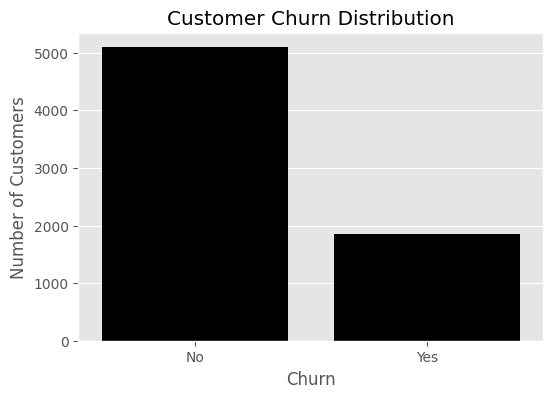

In [9]:
plt.style.use('ggplot')
plt.figure(figsize =(6,4))
sns.countplot(data = df, x = 'Churn', color ='black')
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

In [10]:
num_cols = df.select_dtypes(include = ['number']).columns
num_cols

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='object')

In [11]:
df[num_cols].describe()

,SeniorCitizen,tenure,MonthlyCharges
count,6940.000000,6940.000000,6940.000000
mean,0.163977,32.612392,65.211081
std,0.370281,24.461349,29.904985
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,39.100000
50%,0.000000,29.000000,70.600000
75%,0.000000,56.000000,90.000000
max,1.000000,72.000000,118.750000


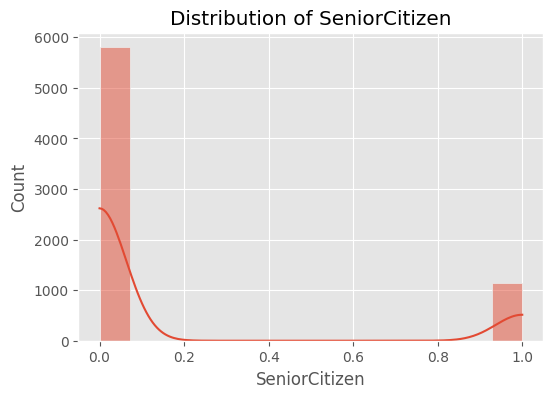

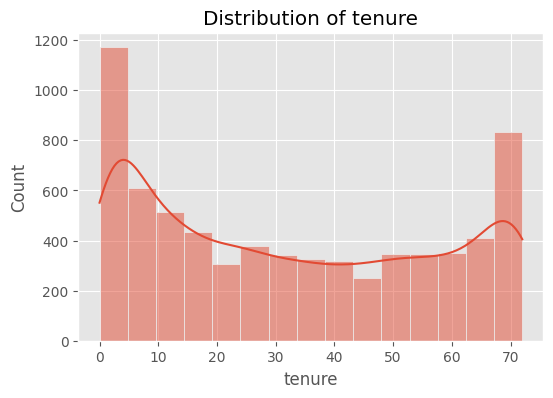

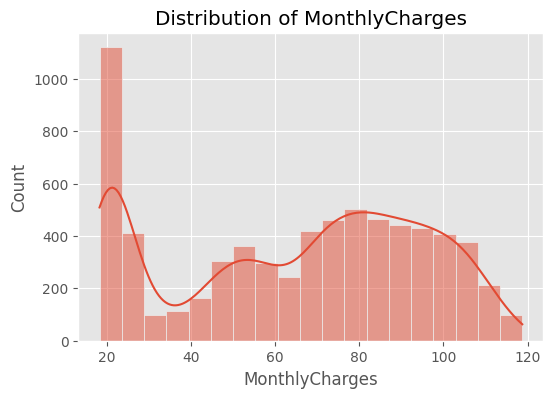

In [12]:
for col in num_cols:
    plt.figure(figsize = (6,4))
    sns.histplot(data = df, x = col, kde = True)
    plt.title(f"Distribution of {col}")
    plt.show()

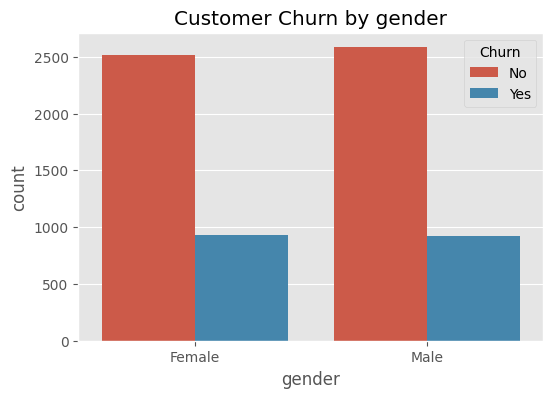

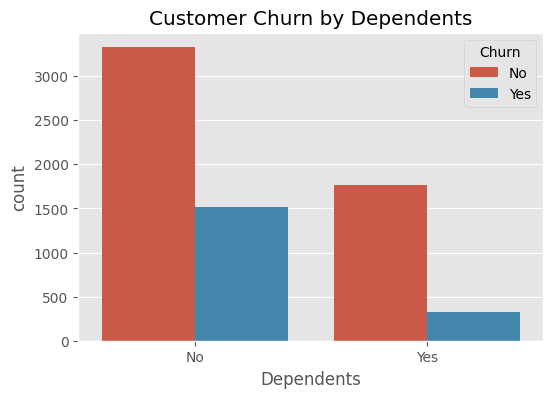

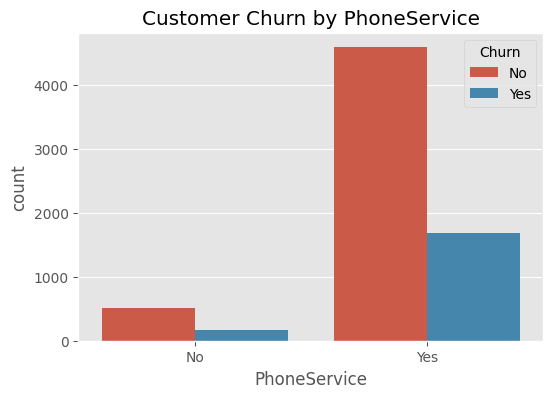

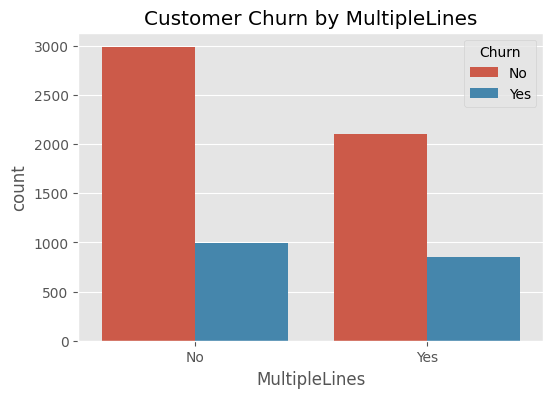

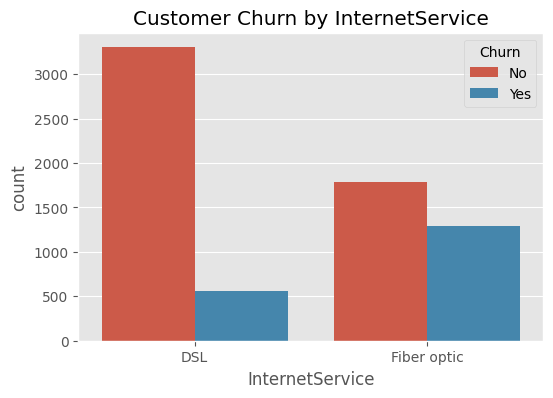

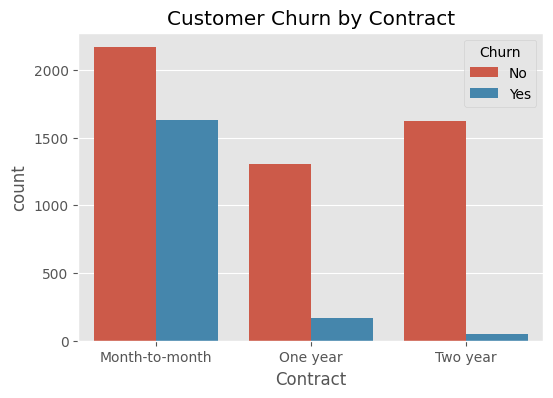

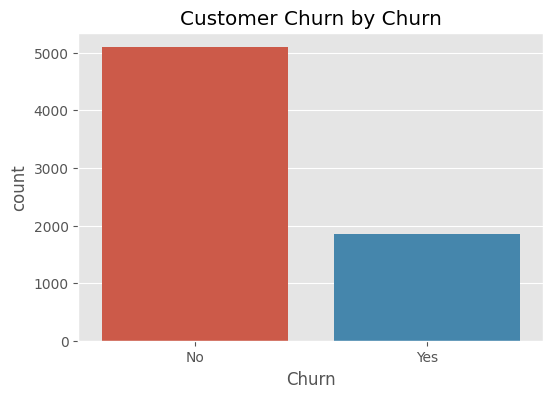

In [13]:
cat_cols = df.select_dtypes(include =['object']).columns
for col in cat_cols:
    plt.figure(figsize =(6,4))
    sns.countplot(data = df, x = col, hue ='Churn')
    plt.title(f"Customer Churn by {col}")
    plt.show()

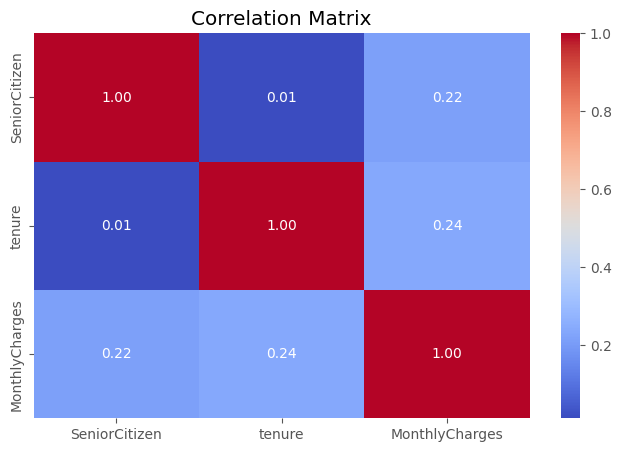

In [14]:
plt.figure(figsize=(8, 5))
sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

In [16]:
# How many customers churned for each contract type?
pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
Contract,,
Month-to-month,57.030016,42.969984
One year,88.692098,11.307902
Two year,97.132616,2.867384
